# 🧠 MindScan — Notebook 1: Classical Models
### NCI H9DAI Research Project 2026

---

## What this notebook does
Trains **4 classical ML models** on **3 datasets**. No GPU needed. Runs in ~20 minutes.

| | Dataset | Task | File to upload |
|---|---|---|---|
| **D1** | Zenodo — depression types | 6-class | `dataset.csv` |
| **D2** | Kaggle — binary depression | Binary | `DA_DB_2.csv` |
| **D3** | Kaggle — suicide risk | Binary | `DA_DB_3.csv` |

## 4 Models trained per dataset
1. Logistic Regression
2. Random Forest
3. SVM (LinearSVC)
4. XGBoost

## Output
All files saved to **Google Drive → MindScan_Models/classical/**

## ⚠️ No GPU needed — use standard CPU runtime

---
# ⚙️ SECTION 0 — Setup

In [ ]:
!pip install -q scikit-learn xgboost imbalanced-learn matplotlib seaborn pandas numpy wordcloud
print('✅ Libraries installed!')

✅ Libraries installed!


In [ ]:
import pandas as pd
import numpy as np
import re, string, os, joblib, warnings
from collections import Counter
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, cohen_kappa_score
)
from imblearn.over_sampling import SMOTE

# Storage for final comparison
ALL_RESULTS = {}
print('✅ Imports done!')

✅ Imports done!


In [ ]:
# ─────────────────────────────────────────────────────────────────
# MOUNT GOOGLE DRIVE — saves everything here so nothing is lost
# even if Colab disconnects mid-run
# ─────────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = '/content/drive/MyDrive/MindScan_Models/classical'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'✅ Drive mounted. Saving to: {SAVE_DIR}')

Mounted at /content/drive
✅ Drive mounted. Saving to: /content/drive/MyDrive/MindScan_Models/classical


In [ ]:
# ─────────────────────────────────────────────────────────────────
# SHARED UTILITY FUNCTIONS — used by all 3 datasets
# ─────────────────────────────────────────────────────────────────

def clean_text(text):
    """
    Cleans one text entry.
    Works on tweets AND Reddit posts.
    Steps: lowercase → remove URLs → remove @mentions →
           remove # symbol → remove punctuation → trim spaces
    """
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def make_tfidf(X_train, X_test, max_features=50000):
    """
    Converts text to TF-IDF number vectors.
    Fit ONLY on training data, transform both sets.
    ngram_range=(1,2) captures single words AND word pairs.
    """
    tfidf = TfidfVectorizer(
        max_features=max_features,
        ngram_range=(1, 2),
        sublinear_tf=True,
        min_df=2
    )
    Xtr = tfidf.fit_transform(X_train)
    Xte = tfidf.transform(X_test)
    return tfidf, Xtr, Xte


def apply_smote(X_train, y_train):
    """
    Balances classes by creating synthetic minority samples.
    ONLY applied to training set — never the test set.
    """
    before = Counter(y_train)
    smote = SMOTE(random_state=42)
    Xb, yb = smote.fit_resample(X_train, y_train)
    after = Counter(yb)
    print(f'   SMOTE: {sum(before.values())} → {sum(after.values())} samples')
    return Xb, yb


def evaluate_model(name, y_true, y_pred, label_names, ds_key, results_store):
    """
    Prints + stores metrics for one model.
    Accuracy, Macro F1, Cohen's Kappa, per-class breakdown.
    Saves confusion matrix chart.
    """
    acc   = accuracy_score(y_true, y_pred)
    macro = f1_score(y_true, y_pred, average='macro')
    kappa = cohen_kappa_score(y_true, y_pred)

    results_store[name] = {
        'accuracy': round(acc, 4),
        'macro_f1': round(macro, 4),
        'kappa':    round(kappa, 4)
    }

    print(f'\n{"="*55}')
    print(f'  {name}  [{ds_key}]')
    print(f'{"="*55}')
    print(f'  Accuracy     : {acc*100:.2f}%')
    print(f'  Macro F1     : {macro:.4f}   ← main metric')
    print(f"  Cohen's Kappa: {kappa:.4f}   ← agreement beyond chance")
    print(f'{"="*55}\n')
    print(classification_report(y_true, y_pred, target_names=label_names, digits=3))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(max(6, len(label_names)*1.4), max(5, len(label_names)*1.1)))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=label_names, yticklabels=label_names,
                cmap='Blues', linewidths=0.4)
    plt.title(f'Confusion Matrix — {name}  [{ds_key}]', fontsize=12, fontweight='bold')
    plt.ylabel('Actual'); plt.xlabel('Predicted')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    chart_path = os.path.join(SAVE_DIR, f'cm_{ds_key}_{name.replace(" ","_")}.png')
    plt.savefig(chart_path, dpi=120, bbox_inches='tight')
    plt.show()


def save_pkl(obj, filename):
    """
    Saves a file to BOTH local Colab storage AND Google Drive.
    Local copy: used immediately in this session.
    Drive copy: safe even if Colab disconnects.
    """
    joblib.dump(obj, filename)
    joblib.dump(obj, os.path.join(SAVE_DIR, filename))
    size_kb = os.path.getsize(filename) / 1024
    print(f'   Saved: {filename}  ({size_kb:.0f} KB)')


def summary_table(results_store, ds_key):
    """
    Prints final comparison of all 4 models for one dataset.
    """
    print(f'\n{"═"*58}')
    print(f'  SUMMARY — {ds_key}')
    print(f'{"═"*58}')
    print(f'  {"Model":<24} {"Accuracy":>10} {"Macro F1":>10} {"Kappa":>8}')
    print(f'  {"-"*54}')
    best = max(results_store.values(), key=lambda x: x['macro_f1'])['macro_f1']
    for name, s in results_store.items():
        star = ' ★' if s['macro_f1'] == best else ''
        print(f'  {name:<24} {s["accuracy"]:>10.4f} {s["macro_f1"]:>10.4f} {s["kappa"]:>8.4f}{star}')
    print(f'{"═"*58}\n')


print('✅ All utility functions ready!')

✅ All utility functions ready!


---
# 📁 DATASET 1 — Depression Type (6 Classes)
**Source:** Nusrat et al. (2024) · Zenodo 14233292  
**Upload:** `dataset.csv`  
**Task:** Which of 6 psychiatric depression types does this text suggest?

In [ ]:
# ─────────────────────────────────────────────────────────────────
# D1 — LOAD
# Upload dataset.csv using the folder icon on the left sidebar.
# ─────────────────────────────────────────────────────────────────
df1 = pd.read_csv('DA_1_DB.csv')
df1 = df1.dropna(subset=['Tweets', 'Labels'])
df1 = df1[df1['Labels'].str.strip() != ''].reset_index(drop=True)

print(f'✅ Dataset 1 loaded: {len(df1):,} rows')
print(df1['Labels'].value_counts())
df1.head(3)

✅ Dataset 1 loaded: 14,983 rows
Labels
postpartum          3746
major depressive    2517
bipolar             2443
psychotic           2312
no                  1985
atypical            1980
Name: count, dtype: int64


,Tweets,Labels
0,I been going thru depression I didnt even rea...,postpartum
1,"@keshab_mahanta hello Health minister sir,I m ...",postpartum
2,FYI in case anyone is concerned - I am NOT act...,postpartum


Dataset 1 — Feature Statistics:
       word_count  char_count  hashtag_count  mention_count
count    14983.00    14983.00       14983.00       14983.00
mean        31.42      173.17           0.07           0.32
std         12.18       66.24           0.41           0.79
min          1.00        6.00           0.00           0.00
25%         22.00      124.00           0.00           0.00
50%         31.00      168.00           0.00           0.00
75%         41.00      235.00           0.00           0.00
max         76.00      411.00           7.00          20.00


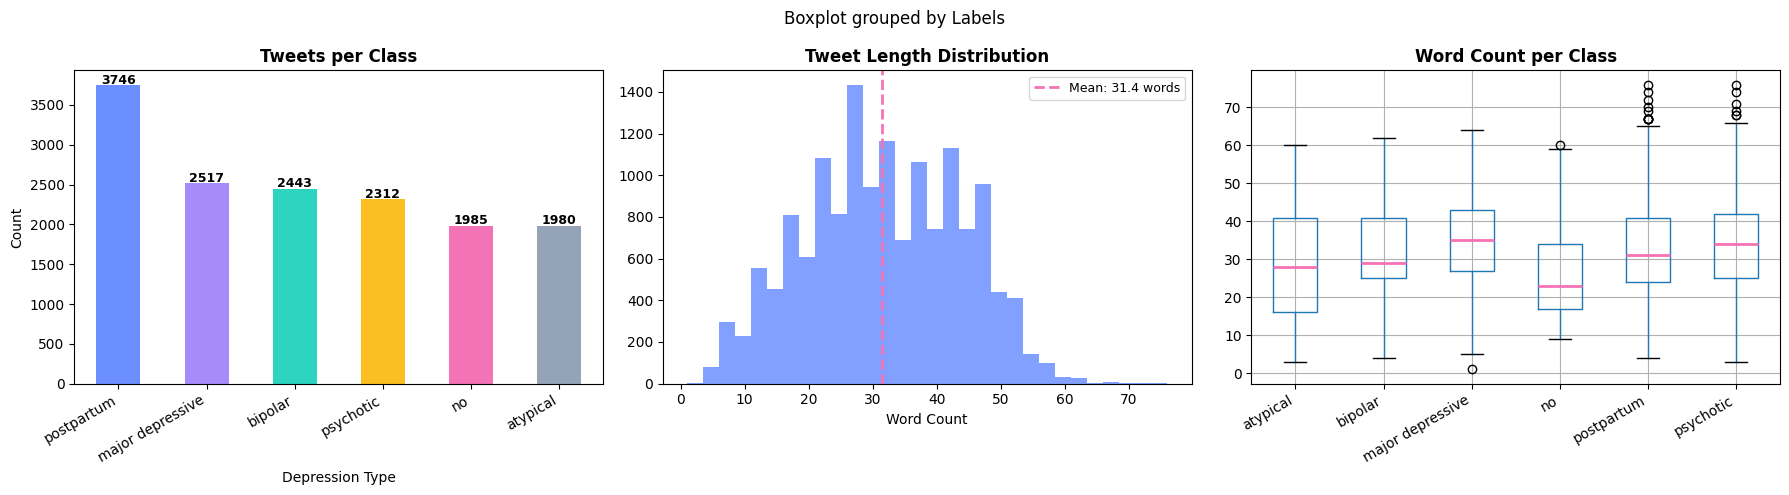


Imbalance ratio: 1.89x
Largest class:  postpartum (3746)
Smallest class: atypical (1980)


In [ ]:
# ─────────────────────────────────────────────────────────────────
# D1 — EDA
# Check: class distribution, tweet length, imbalance ratio
# ─────────────────────────────────────────────────────────────────
label_counts1 = df1['Labels'].value_counts()
df1['word_count'] = df1['Tweets'].apply(lambda x: len(str(x).split()))
df1['char_count'] = df1['Tweets'].apply(lambda x: len(str(x)))
df1['hashtag_count'] = df1['Tweets'].apply(lambda x: str(x).count('#'))
df1['mention_count'] = df1['Tweets'].apply(lambda x: len(re.findall(r'@\w+', str(x))))
df1['exclamation_count'] = df1['Tweets'].apply(lambda x: str(x).count('!'))
df1['question_count'] = df1['Tweets'].apply(lambda x: str(x).count('?'))

print('Dataset 1 — Feature Statistics:')
print(df1[['word_count','char_count','hashtag_count','mention_count']].describe().round(2))

colors = ['#6c8fff','#a78bfa','#2dd4bf','#fbbf24','#f472b6','#94a3b8']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Dataset 1 EDA — Depression Type (6 Classes)', fontsize=14, fontweight='bold')

# Class distribution
label_counts1.plot(kind='bar', ax=axes[0], color=colors, edgecolor='none')
axes[0].set_title('Tweets per Class', fontweight='bold')
axes[0].set_xlabel('Depression Type'); axes[0].set_ylabel('Count')
axes[0].set_xticklabels(label_counts1.index, rotation=30, ha='right')
for i, v in enumerate(label_counts1.values):
    axes[0].text(i, v+20, str(v), ha='center', fontsize=9, fontweight='bold')

# Word count histogram
axes[1].hist(df1['word_count'], bins=30, color='#6c8fff', edgecolor='none', alpha=0.85)
axes[1].axvline(df1['word_count'].mean(), color='#f472b6', linestyle='--', linewidth=2,
                label=f'Mean: {df1["word_count"].mean():.1f} words')
axes[1].set_title('Tweet Length Distribution', fontweight='bold')
axes[1].set_xlabel('Word Count'); axes[1].legend(fontsize=9)

# Box plot per class
df1.boxplot(column='word_count', by='Labels', ax=axes[2],
            medianprops=dict(color='#f472b6', linewidth=2))
axes[2].set_title('Word Count per Class', fontweight='bold')
axes[2].set_xlabel(''); plt.sca(axes[2]); plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'eda_d1.png'), dpi=130, bbox_inches='tight')
plt.show()

print(f'\nImbalance ratio: {label_counts1.max()/label_counts1.min():.2f}x')
print(f'Largest class:  {label_counts1.idxmax()} ({label_counts1.max()})')
print(f'Smallest class: {label_counts1.idxmin()} ({label_counts1.min()})')

In [ ]:
# ─────────────────────────────────────────────────────────────────
# D1 — PREPROCESS: Clean text + encode labels
# ─────────────────────────────────────────────────────────────────
print('Cleaning tweets...')
df1['clean'] = df1['Tweets'].apply(clean_text)

# Show before/after example
print('\nBefore:', df1['Tweets'].iloc[0])
print('After: ', df1['clean'].iloc[0])

# Encode labels to numbers
le1 = LabelEncoder()
df1['label_enc'] = le1.fit_transform(df1['Labels'])

print('\nLabel encoding:')
for i, c in enumerate(le1.classes_):
    print(f'  {i} → {c}  ({(df1["Labels"]==c).sum()} tweets)')

# Save label encoder immediately
save_pkl(le1, 'le_d1.pkl')

X1 = df1['clean']
y1 = df1['label_enc']
print(f'\n✅ D1 preprocessed: {len(X1)} samples, {len(le1.classes_)} classes')

Cleaning tweets...

Before: I been going thru depression  I didnt even realize it till a couple weeks ago I always said Im strong Im not gone go thru that I got this but your emotions change your body changes your mind changes after a baby like I just pushed a whole human outta me I need time
After:  i been going thru depression i didnt even realize it till a couple weeks ago i always said im strong im not gone go thru that i got this but your emotions change your body changes your mind changes after a baby like i just pushed a whole human outta me i need time

Label encoding:
  0 → atypical  (1980 tweets)
  1 → bipolar  (2443 tweets)
  2 → major depressive  (2517 tweets)
  3 → no  (1985 tweets)
  4 → postpartum  (3746 tweets)
  5 → psychotic  (2312 tweets)
   Saved: le_d1.pkl  (1 KB)

✅ D1 preprocessed: 14983 samples, 6 classes


In [ ]:
# ─────────────────────────────────────────────────────────────────
# D1 — SPLIT → TF-IDF → SMOTE
#
# 80/20 split (same as Tumaliuan et al. 2024 — keeps results comparable)
# TF-IDF converts text to numbers the models can read
# SMOTE balances classes (fixes the imbalance the base paper ignored)
# ─────────────────────────────────────────────────────────────────
X1_tr, X1_te, y1_tr, y1_te = train_test_split(
    X1, y1, test_size=0.2, stratify=y1, random_state=42
)
print(f'Split: {len(X1_tr)} train / {len(X1_te)} test')

tfidf1, X1_tr_tf, X1_te_tf = make_tfidf(X1_tr, X1_te)
print(f'TF-IDF shape: {X1_tr_tf.shape}  (tweets × features)')

print('Applying SMOTE...')
X1_bal, y1_bal = apply_smote(X1_tr_tf, y1_tr)

# Save TF-IDF — needed to process new text in the UI later
save_pkl(tfidf1, 'tfidf_d1.pkl')
print('✅ D1 ready for model training.')

Split: 11986 train / 2997 test
TF-IDF shape: (11986, 34615)  (tweets × features)
Applying SMOTE...
   SMOTE: 11986 → 17982 samples
   Saved: tfidf_d1.pkl  (1338 KB)
✅ D1 ready for model training.



Training Logistic Regression...

  Logistic Regression  [D1]
  Accuracy     : 91.52%
  Macro F1     : 0.9179   ← main metric
  Cohen's Kappa: 0.8971   ← agreement beyond chance

                  precision    recall  f1-score   support

        atypical      0.995     0.962     0.978       396
         bipolar      0.965     0.945     0.955       489
major depressive      0.855     0.831     0.843       504
              no      0.922     0.985     0.952       397
      postpartum      0.916     0.921     0.919       749
       psychotic      0.855     0.866     0.860       462

        accuracy                          0.915      2997
       macro avg      0.918     0.918     0.918      2997
    weighted avg      0.916     0.915     0.915      2997



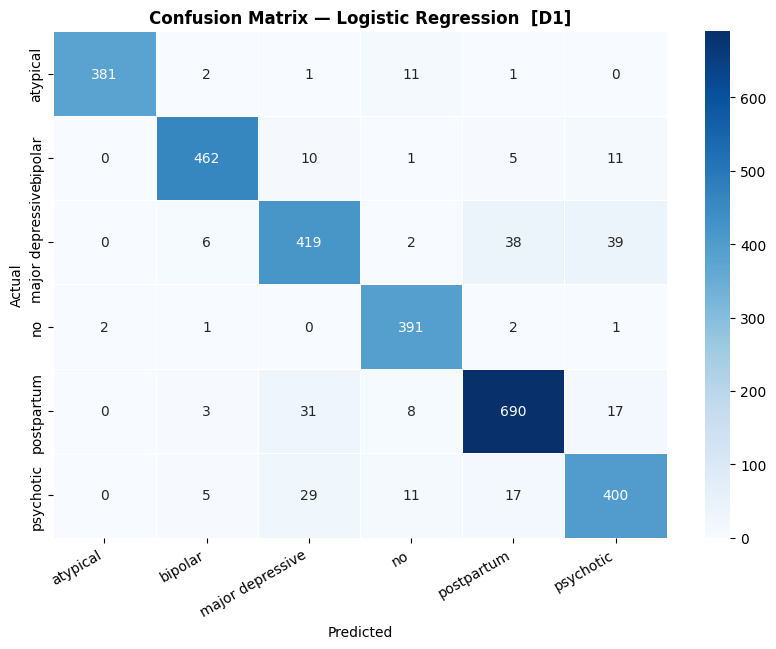

   Saved: logistic_regression_d1.pkl  (1624 KB)

Training Random Forest...

  Random Forest  [D1]
  Accuracy     : 90.89%
  Macro F1     : 0.9129   ← main metric
  Cohen's Kappa: 0.8891   ← agreement beyond chance

                  precision    recall  f1-score   support

        atypical      0.990     0.962     0.976       396
         bipolar      0.969     0.949     0.959       489
major depressive      0.928     0.746     0.827       504
              no      0.935     0.985     0.960       397
      postpartum      0.839     0.955     0.893       749
       psychotic      0.867     0.859     0.863       462

        accuracy                          0.909      2997
       macro avg      0.921     0.909     0.913      2997
    weighted avg      0.912     0.909     0.908      2997



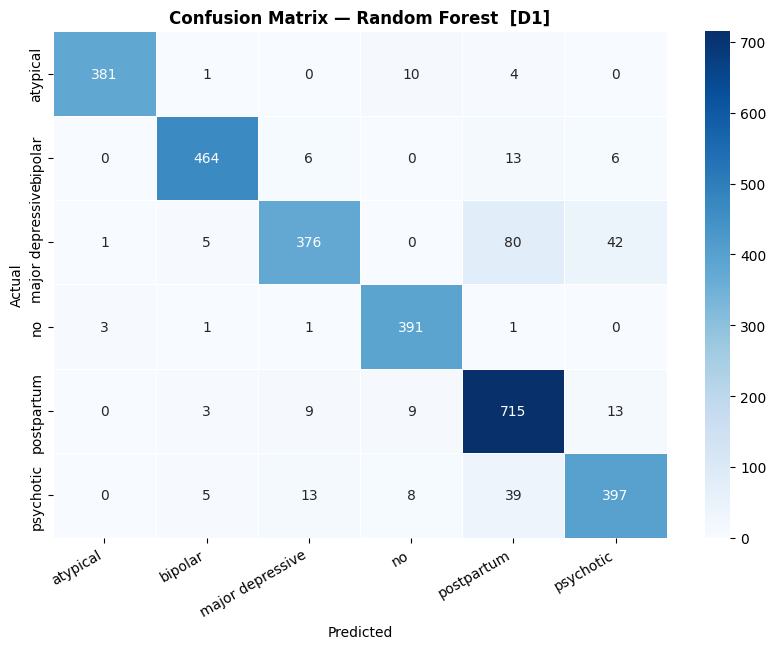

   Saved: random_forest_d1.pkl  (246200 KB)

Training SVM...

  SVM  [D1]
  Accuracy     : 92.36%
  Macro F1     : 0.9269   ← main metric
  Cohen's Kappa: 0.9072   ← agreement beyond chance

                  precision    recall  f1-score   support

        atypical      0.995     0.970     0.982       396
         bipolar      0.963     0.947     0.955       489
major depressive      0.857     0.853     0.855       504
              no      0.958     0.982     0.970       397
      postpartum      0.922     0.925     0.923       749
       psychotic      0.870     0.883     0.876       462

        accuracy                          0.924      2997
       macro avg      0.927     0.927     0.927      2997
    weighted avg      0.924     0.924     0.924      2997



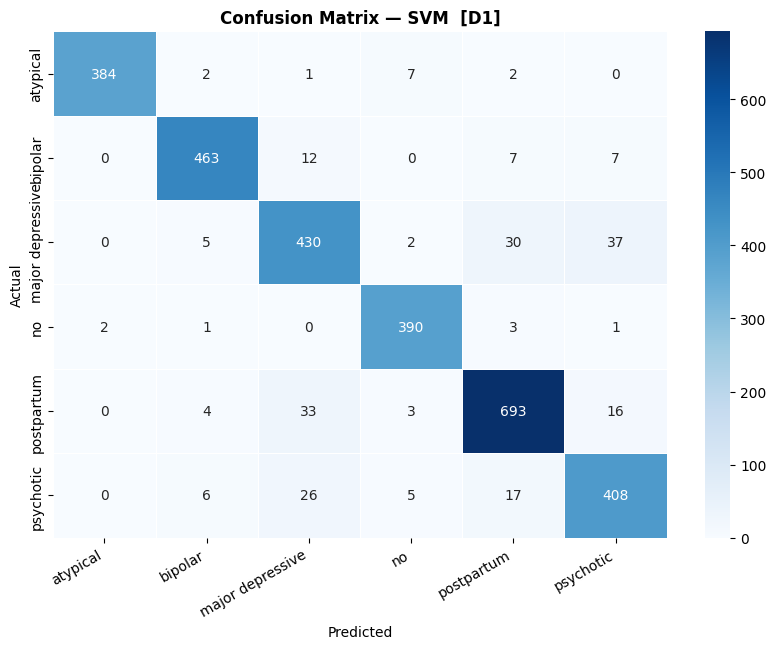

   Saved: svm_d1.pkl  (1623 KB)

Training XGBoost...

  XGBoost  [D1]
  Accuracy     : 91.76%
  Macro F1     : 0.9217   ← main metric
  Cohen's Kappa: 0.9000   ← agreement beyond chance

                  precision    recall  f1-score   support

        atypical      0.992     0.965     0.978       396
         bipolar      0.959     0.955     0.957       489
major depressive      0.861     0.845     0.853       504
              no      0.944     0.980     0.962       397
      postpartum      0.903     0.911     0.907       749
       psychotic      0.873     0.874     0.874       462

        accuracy                          0.918      2997
       macro avg      0.922     0.922     0.922      2997
    weighted avg      0.918     0.918     0.918      2997



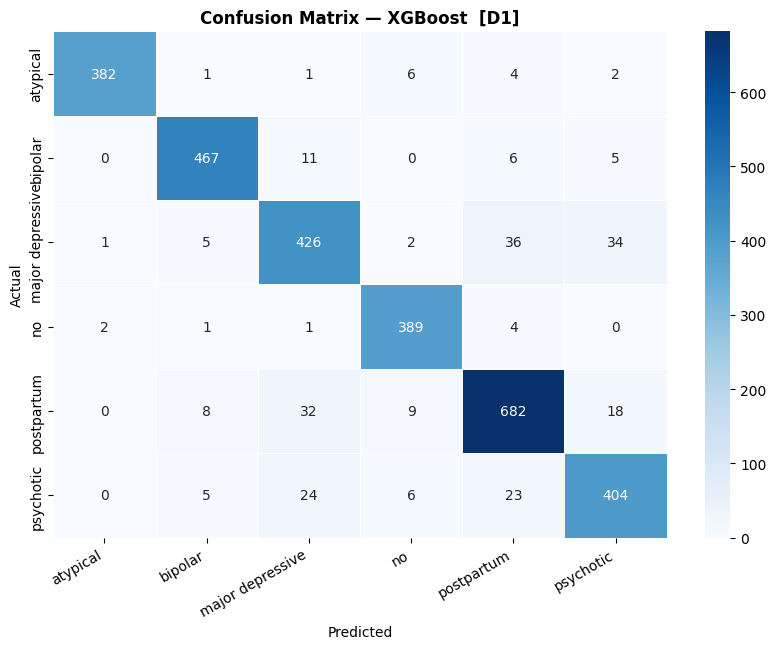

   Saved: xgboost_d1.pkl  (3102 KB)

══════════════════════════════════════════════════════════
  SUMMARY — D1 — Depression Type
══════════════════════════════════════════════════════════
  Model                      Accuracy   Macro F1    Kappa
  ------------------------------------------------------
  Logistic Regression          0.9152     0.9179   0.8971
  Random Forest                0.9089     0.9129   0.8891
  SVM                          0.9236     0.9269   0.9072 ★
  XGBoost                      0.9176     0.9217   0.9000
══════════════════════════════════════════════════════════


✅ Dataset 1 complete! All files saved to Drive.


In [ ]:
# ─────────────────────────────────────────────────────────────────
# D1 — TRAIN + EVALUATE 4 CLASSICAL MODELS
#
# Model 1: Logistic Regression — simple linear classifier, good baseline
# Model 2: Random Forest       — 300 decision trees voting together
#                                 (used in Tumaliuan 2024 — kept for comparison)
# Model 3: SVM (LinearSVC)     — gold standard for text classification
# Model 4: XGBoost             — gradient boosting, strong on imbalanced data
# ─────────────────────────────────────────────────────────────────
d1_results = {}

models_d1 = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42, n_jobs=-1),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1),
    'SVM': LinearSVC(
        C=1.0, class_weight='balanced', max_iter=2000, random_state=42),
    'XGBoost': XGBClassifier(
        n_estimators=300, learning_rate=0.1, max_depth=6,
        eval_metric='mlogloss', random_state=42, n_jobs=-1)
}

for name, model in models_d1.items():
    print(f'\nTraining {name}...')
    model.fit(X1_bal, y1_bal)
    preds = model.predict(X1_te_tf)
    evaluate_model(name, y1_te, preds, le1.classes_, 'D1', d1_results)
    safe = name.lower().replace(' ', '_')
    save_pkl(model, f'{safe}_d1.pkl')

ALL_RESULTS['D1 Depression Type'] = d1_results
summary_table(d1_results, 'D1 — Depression Type')
print('\n✅ Dataset 1 complete! All files saved to Drive.')

---
# 📁 DATASET 2 — Binary Depression Detection
**Source:** albertobellardini/depression-twitter · Kaggle  
**Upload:** `DA_DB_2.csv`  
**Columns:** `Index` | `message to examine` | `label (depression result)`  
**Task:** Is this text depressed or not?

In [ ]:
# ─────────────────────────────────────────────────────────────────
# D2 — LOAD + STANDARDISE COLUMNS
# We know the exact column names from the dataset.
# ─────────────────────────────────────────────────────────────────
df2 = pd.read_csv('DA_DB_2.csv')
print(f'Raw shape: {df2.shape}')
print(f'Columns: {list(df2.columns)}')
print(df2.head(3))

Raw shape: (10314, 3)
Columns: ['Index', 'message to examine', 'label (depression result)']
   Index                                 message to examine  \
0    106  just had a real good moment. i missssssssss hi...   
1    217         is reading manga  http://plurk.com/p/mzp1e   
2    220  @comeagainjen http://twitpic.com/2y2lx - http:...   

   label (depression result)  
0                          0  
1                          0  
2                          0  


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ─────────────────────────────────────────────────────────────────
# Rename to standard: text + label
# ─────────────────────────────────────────────────────────────────
df2 = df2.rename(columns={
    'message to examine': 'text',
    'label (depression result)': 'label'
})
if 'Index' in df2.columns:
    df2 = df2.drop(columns=['Index'])

df2 = df2[['text','label']].dropna().reset_index(drop=True)
df2['label'] = df2['label'].astype(str).str.strip().str.lower()

print('Label distribution:')
print(df2['label'].value_counts())
print(f'\nTotal clean rows: {len(df2):,}')
print(df2.head(3))

Label distribution:
label
0    8000
1    2314
Name: count, dtype: int64

Total clean rows: 10,314
                                                text label
0  just had a real good moment. i missssssssss hi...     0
1         is reading manga  http://plurk.com/p/mzp1e     0
2  @comeagainjen http://twitpic.com/2y2lx - http:...     0


Dataset 2 Statistics:
       word_count  char_count
count    10314.00    10314.00
mean        15.07       92.62
std         10.13       64.67
min          1.00        1.00
25%          8.00       48.00
50%         13.00       78.00
75%         20.00      119.00
max         92.00      874.00


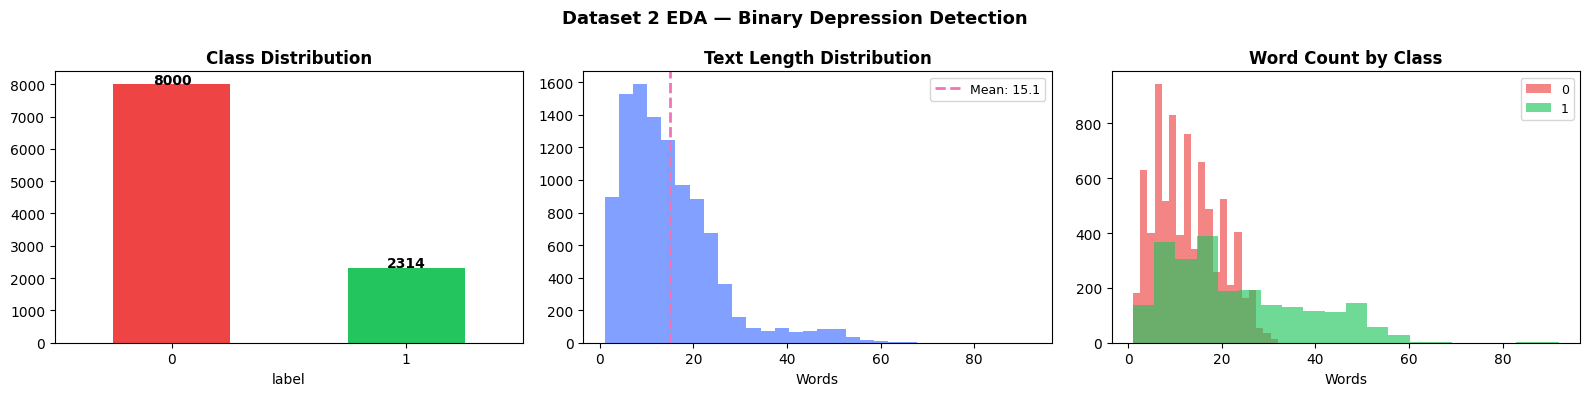

Imbalance ratio: 3.46x


In [ ]:
# ─────────────────────────────────────────────────────────────────
# D2 — EDA
# ─────────────────────────────────────────────────────────────────
label_counts2 = df2['label'].value_counts()
df2['word_count'] = df2['text'].apply(lambda x: len(str(x).split()))
df2['char_count'] = df2['text'].apply(lambda x: len(str(x)))

print('Dataset 2 Statistics:')
print(df2[['word_count','char_count']].describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Dataset 2 EDA — Binary Depression Detection', fontsize=13, fontweight='bold')

label_counts2.plot(kind='bar', ax=axes[0], color=['#ef4444','#22c55e'], edgecolor='none')
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_xticklabels(label_counts2.index, rotation=0)
for i, v in enumerate(label_counts2.values):
    axes[0].text(i, v+20, str(v), ha='center', fontsize=10, fontweight='bold')

axes[1].hist(df2['word_count'], bins=30, color='#6c8fff', edgecolor='none', alpha=0.85)
axes[1].axvline(df2['word_count'].mean(), color='#f472b6', linestyle='--', linewidth=2,
                label=f'Mean: {df2["word_count"].mean():.1f}')
axes[1].set_title('Text Length Distribution', fontweight='bold')
axes[1].set_xlabel('Words'); axes[1].legend(fontsize=9)

for lbl, color in zip(df2['label'].unique(), ['#ef4444','#22c55e']):
    axes[2].hist(df2[df2['label']==lbl]['word_count'], bins=20,
                 alpha=0.65, color=color, label=lbl, edgecolor='none')
axes[2].set_title('Word Count by Class', fontweight='bold')
axes[2].set_xlabel('Words'); axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'eda_d2.png'), dpi=130, bbox_inches='tight')
plt.show()
print(f'Imbalance ratio: {label_counts2.max()/label_counts2.min():.2f}x')

In [ ]:
# ─────────────────────────────────────────────────────────────────
# D2 — PREPROCESS + SPLIT + TF-IDF + SMOTE
# ─────────────────────────────────────────────────────────────────
print('Cleaning text...')
df2['clean'] = df2['text'].apply(clean_text)

print('\nBefore:', str(df2['text'].iloc[0])[:80])
print('After: ', str(df2['clean'].iloc[0])[:80])

le2 = LabelEncoder()
df2['label_enc'] = le2.fit_transform(df2['label'])
save_pkl(le2, 'le_d2.pkl')

print('\nLabel encoding:')
for i, c in enumerate(le2.classes_):
    print(f'  {i} → {c}  ({(df2["label"]==c).sum()} samples)')

X2 = df2['clean']; y2 = df2['label_enc']

X2_tr, X2_te, y2_tr, y2_te = train_test_split(
    X2, y2, test_size=0.2, stratify=y2, random_state=42)

tfidf2, X2_tr_tf, X2_te_tf = make_tfidf(X2_tr, X2_te)
save_pkl(tfidf2, 'tfidf_d2.pkl')
print(f'TF-IDF shape: {X2_tr_tf.shape}')

print('Applying SMOTE...')
X2_bal, y2_bal = apply_smote(X2_tr_tf, y2_tr)
print('✅ D2 ready.')

Cleaning text...

Before: just had a real good moment. i missssssssss him so much, 
After:  just had a real good moment i missssssssss him so much
   Saved: le_d2.pkl  (0 KB)

Label encoding:
  0 → 0  (8000 samples)
  1 → 1  (2314 samples)
   Saved: tfidf_d2.pkl  (569 KB)
TF-IDF shape: (8251, 15240)
Applying SMOTE...
   SMOTE: 8251 → 12800 samples
✅ D2 ready.



Training Logistic Regression...

  Logistic Regression  [D2]
  Accuracy     : 98.89%
  Macro F1     : 0.9839   ← main metric
  Cohen's Kappa: 0.9678   ← agreement beyond chance

              precision    recall  f1-score   support

           0      0.990     0.996     0.993      1600
           1      0.985     0.965     0.975       463

    accuracy                          0.989      2063
   macro avg      0.987     0.981     0.984      2063
weighted avg      0.989     0.989     0.989      2063



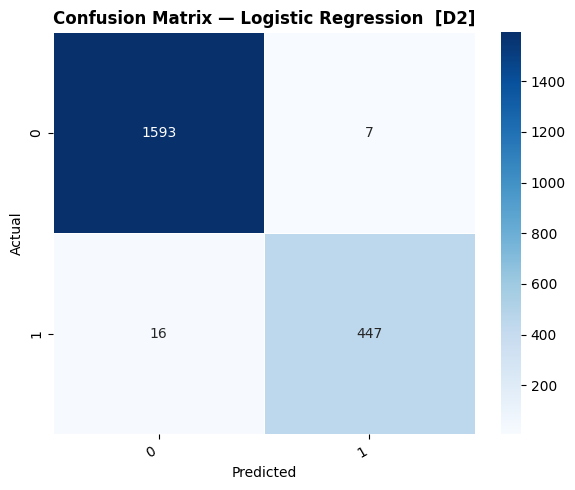

   Saved: logistic_regression_d2.pkl  (120 KB)

Training Random Forest...

  Random Forest  [D2]
  Accuracy     : 99.18%
  Macro F1     : 0.9880   ← main metric
  Cohen's Kappa: 0.9760   ← agreement beyond chance

              precision    recall  f1-score   support

           0      0.989     1.000     0.995      1600
           1      1.000     0.963     0.981       463

    accuracy                          0.992      2063
   macro avg      0.995     0.982     0.988      2063
weighted avg      0.992     0.992     0.992      2063



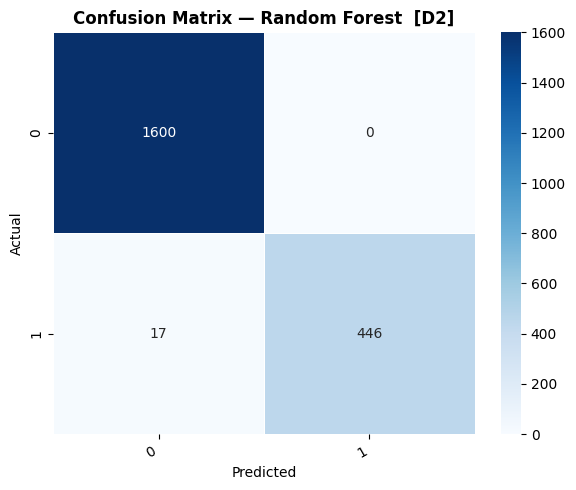

   Saved: random_forest_d2.pkl  (73424 KB)

Training SVM...

  SVM  [D2]
  Accuracy     : 97.09%
  Macro F1     : 0.9589   ← main metric
  Cohen's Kappa: 0.9177   ← agreement beyond chance

              precision    recall  f1-score   support

           0      0.987     0.975     0.981      1600
           1      0.917     0.957     0.937       463

    accuracy                          0.971      2063
   macro avg      0.952     0.966     0.959      2063
weighted avg      0.972     0.971     0.971      2063



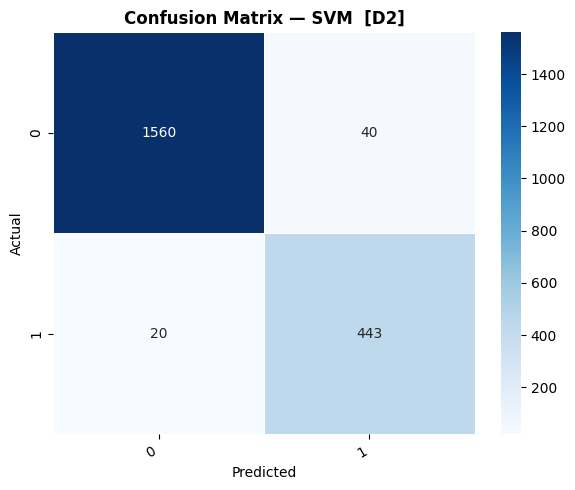

   Saved: svm_d2.pkl  (120 KB)

Training XGBoost...

  XGBoost  [D2]
  Accuracy     : 99.27%
  Macro F1     : 0.9895   ← main metric
  Cohen's Kappa: 0.9789   ← agreement beyond chance

              precision    recall  f1-score   support

           0      0.991     0.999     0.995      1600
           1      0.998     0.970     0.984       463

    accuracy                          0.993      2063
   macro avg      0.995     0.985     0.989      2063
weighted avg      0.993     0.993     0.993      2063



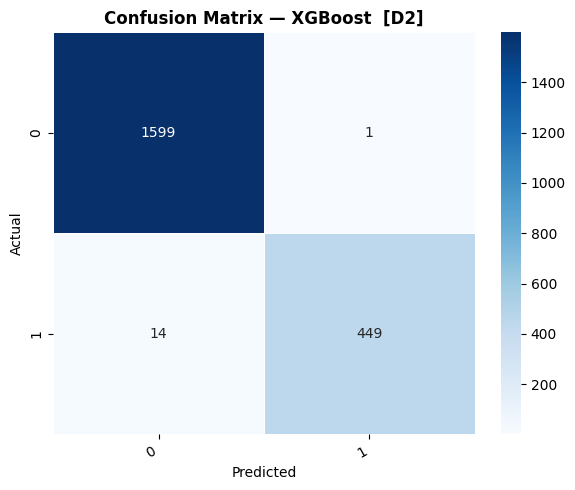

   Saved: xgboost_d2.pkl  (362 KB)

══════════════════════════════════════════════════════════
  SUMMARY — D2 — Binary Depression
══════════════════════════════════════════════════════════
  Model                      Accuracy   Macro F1    Kappa
  ------------------------------------------------------
  Logistic Regression          0.9889     0.9839   0.9678
  Random Forest                0.9918     0.9880   0.9760
  SVM                          0.9709     0.9589   0.9177
  XGBoost                      0.9927     0.9895   0.9789 ★
══════════════════════════════════════════════════════════


✅ Dataset 2 complete! All files saved to Drive.


In [ ]:
# ─────────────────────────────────────────────────────────────────
# D2 — TRAIN + EVALUATE 4 CLASSICAL MODELS
# ─────────────────────────────────────────────────────────────────
d2_results = {}

models_d2 = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42, n_jobs=-1),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1),
    'SVM': LinearSVC(
        C=1.0, class_weight='balanced', max_iter=2000, random_state=42),
    'XGBoost': XGBClassifier(
        n_estimators=300, learning_rate=0.1, max_depth=6,
        eval_metric='logloss', random_state=42, n_jobs=-1)
}

for name, model in models_d2.items():
    print(f'\nTraining {name}...')
    model.fit(X2_bal, y2_bal)
    preds = model.predict(X2_te_tf)
    evaluate_model(name, y2_te, preds, le2.classes_, 'D2', d2_results)
    safe = name.lower().replace(' ', '_')
    save_pkl(model, f'{safe}_d2.pkl')

ALL_RESULTS['D2 Binary Depression'] = d2_results
summary_table(d2_results, 'D2 — Binary Depression')
print('\n✅ Dataset 2 complete! All files saved to Drive.')

---
# 📁 DATASET 3 — Suicide Risk Detection
**Source:** nikhileswarkomati/suicide-watch · Kaggle (Reddit)  
**Upload:** `DA_DB_3.csv`  
**Columns:** `text` | `class` (suicide / non-suicide)  
**Task:** Is there suicide risk in this text?

**Note:** This dataset has ~232K rows. We sample 25K per class for Colab speed.  
Reddit posts are longer than tweets — we use `max_features=60000` for TF-IDF.

In [ ]:
# ─────────────────────────────────────────────────────────────────
# D3 — LOAD + STANDARDISE
# ─────────────────────────────────────────────────────────────────
df3 = pd.read_csv('DA_DB_3.csv')
print(f'Raw shape: {df3.shape}')
print(f'Columns: {list(df3.columns)}')

# Standardise column names
col_map = {}
for col in df3.columns:
    if col.lower() == 'class':
        col_map[col] = 'label'
    elif col.lower() == 'text':
        col_map[col] = 'text'
df3 = df3.rename(columns=col_map)

df3 = df3[['text','label']].dropna().reset_index(drop=True)
df3['label'] = df3['label'].astype(str).str.strip().str.lower()

print(f'\nFull distribution:')
print(df3['label'].value_counts())

# Sample 25K per class — keeps Colab RAM under control
# Remove this block if you have Colab Pro or run locally
df3 = df3.groupby('label').apply(
    lambda x: x.sample(min(25000, len(x)), random_state=42)
).reset_index(drop=True)

print(f'\nUsing sample:')
print(df3['label'].value_counts())
print(f'Total: {len(df3):,} rows')
df3.head(3)

Raw shape: (232074, 3)
Columns: ['Unnamed: 0', 'text', 'class']

Full distribution:
label
suicide        116037
non-suicide    116037
Name: count, dtype: int64

Using sample:
label
non-suicide    25000
suicide        25000
Name: count, dtype: int64
Total: 50,000 rows


,text,label
0,Used to keep it cool Used to be a fool \n\nAll...,non-suicide
1,"Well, haven't mat a girl like this in a while ...",non-suicide
2,My girlfriend just left me👍👍👍👍👍😁😁😁😁😁 I don't w...,non-suicide


Dataset 3 Statistics:
       word_count  char_count
count    50000.00    50000.00
mean       131.48      686.67
std        226.47     1182.62
min          1.00        4.00
25%         26.00      138.00
50%         60.00      313.00
75%        154.00      796.00
max       9684.00    38785.00

Word count by class:
  non-suicide: avg 62.2 words
  suicide: avg 200.8 words


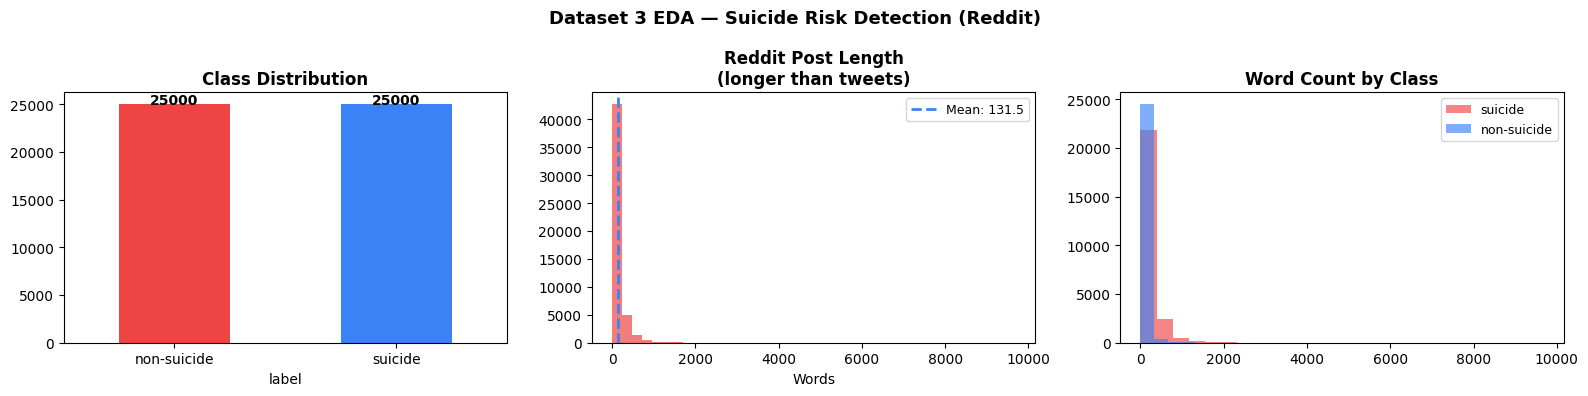

In [ ]:
# ─────────────────────────────────────────────────────────────────
# D3 — EDA
# Reddit posts are much longer than tweets — important to show in paper
# ─────────────────────────────────────────────────────────────────
df3['word_count'] = df3['text'].apply(lambda x: len(str(x).split()))
df3['char_count'] = df3['text'].apply(lambda x: len(str(x)))
label_counts3 = df3['label'].value_counts()

print('Dataset 3 Statistics:')
print(df3[['word_count','char_count']].describe().round(2))
print('\nWord count by class:')
for lbl in df3['label'].unique():
    mean_wc = df3[df3['label']==lbl]['word_count'].mean()
    print(f'  {lbl}: avg {mean_wc:.1f} words')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Dataset 3 EDA — Suicide Risk Detection (Reddit)', fontsize=13, fontweight='bold')

label_counts3.plot(kind='bar', ax=axes[0], color=['#ef4444','#3b82f6'], edgecolor='none')
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_xticklabels(label_counts3.index, rotation=0)
for i, v in enumerate(label_counts3.values):
    axes[0].text(i, v+50, str(v), ha='center', fontsize=10, fontweight='bold')

axes[1].hist(df3['word_count'], bins=40, color='#ef4444', edgecolor='none', alpha=0.7)
axes[1].axvline(df3['word_count'].mean(), color='#3b82f6', linestyle='--', linewidth=2,
                label=f'Mean: {df3["word_count"].mean():.1f}')
axes[1].set_title('Reddit Post Length\n(longer than tweets)', fontweight='bold')
axes[1].set_xlabel('Words'); axes[1].legend(fontsize=9)

for lbl, color in zip(['suicide','non-suicide'], ['#ef4444','#3b82f6']):
    if lbl in df3['label'].values:
        axes[2].hist(df3[df3['label']==lbl]['word_count'], bins=25,
                     alpha=0.65, color=color, label=lbl, edgecolor='none')
axes[2].set_title('Word Count by Class', fontweight='bold')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'eda_d3.png'), dpi=130, bbox_inches='tight')
plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────────
# D3 — PREPROCESS + SPLIT + TF-IDF
# No SMOTE needed — dataset is already balanced (25K each class)
# max_features=60000 because Reddit posts are longer than tweets
# ─────────────────────────────────────────────────────────────────
print('Cleaning text...')
df3['clean'] = df3['text'].apply(clean_text)

print('\nBefore:', str(df3['text'].iloc[0])[:80])
print('After: ', str(df3['clean'].iloc[0])[:80])

le3 = LabelEncoder()
df3['label_enc'] = le3.fit_transform(df3['label'])
save_pkl(le3, 'le_d3.pkl')

print('\nLabel encoding:')
for i, c in enumerate(le3.classes_):
    print(f'  {i} → {c}')

X3 = df3['clean']; y3 = df3['label_enc']

X3_tr, X3_te, y3_tr, y3_te = train_test_split(
    X3, y3, test_size=0.2, stratify=y3, random_state=42)

# Larger vocabulary for longer Reddit posts
tfidf3, X3_tr_tf, X3_te_tf = make_tfidf(X3_tr, X3_te, max_features=60000)
save_pkl(tfidf3, 'tfidf_d3.pkl')
print(f'TF-IDF shape: {X3_tr_tf.shape}')
print('\nDataset is balanced — SMOTE not needed.')
print('✅ D3 ready.')

Cleaning text...

Before: Used to keep it cool Used to be a fool 

All about the bounce in my step

Watch 
After:  used to keep it cool used to be a fool all about the bounce in my step watch it 
   Saved: le_d3.pkl  (0 KB)

Label encoding:
  0 → non-suicide
  1 → suicide
   Saved: tfidf_d3.pkl  (2300 KB)
TF-IDF shape: (40000, 60000)

Dataset is balanced — SMOTE not needed.
✅ D3 ready.



Training Logistic Regression...

  Logistic Regression  [D3]
  Accuracy     : 93.18%
  Macro F1     : 0.9318   ← main metric
  Cohen's Kappa: 0.8636   ← agreement beyond chance

              precision    recall  f1-score   support

 non-suicide      0.923     0.942     0.933      5000
     suicide      0.941     0.921     0.931      5000

    accuracy                          0.932     10000
   macro avg      0.932     0.932     0.932     10000
weighted avg      0.932     0.932     0.932     10000



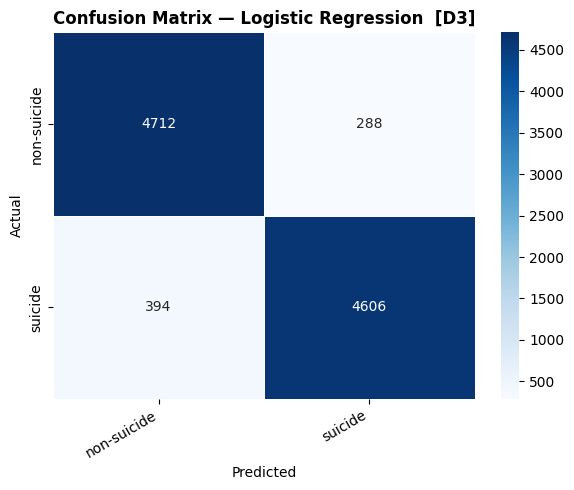

   Saved: logistic_regression_d3.pkl  (470 KB)

Training Random Forest...

  Random Forest  [D3]
  Accuracy     : 88.00%
  Macro F1     : 0.8800   ← main metric
  Cohen's Kappa: 0.7600   ← agreement beyond chance

              precision    recall  f1-score   support

 non-suicide      0.874     0.889     0.881      5000
     suicide      0.887     0.871     0.879      5000

    accuracy                          0.880     10000
   macro avg      0.880     0.880     0.880     10000
weighted avg      0.880     0.880     0.880     10000



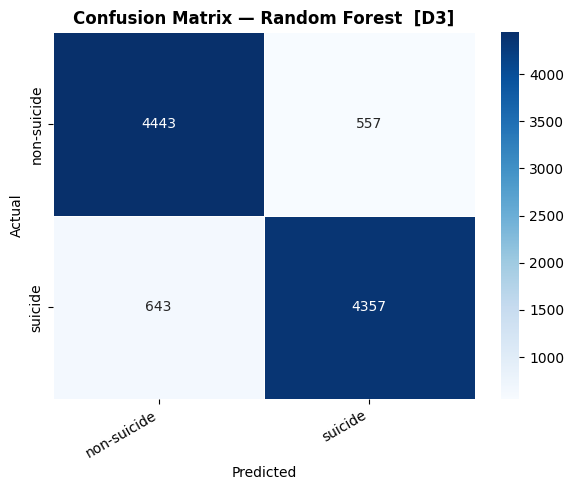

   Saved: random_forest_d3.pkl  (341926 KB)

Training SVM...

  SVM  [D3]
  Accuracy     : 93.68%
  Macro F1     : 0.9368   ← main metric
  Cohen's Kappa: 0.8736   ← agreement beyond chance

              precision    recall  f1-score   support

 non-suicide      0.931     0.943     0.937      5000
     suicide      0.942     0.930     0.936      5000

    accuracy                          0.937     10000
   macro avg      0.937     0.937     0.937     10000
weighted avg      0.937     0.937     0.937     10000



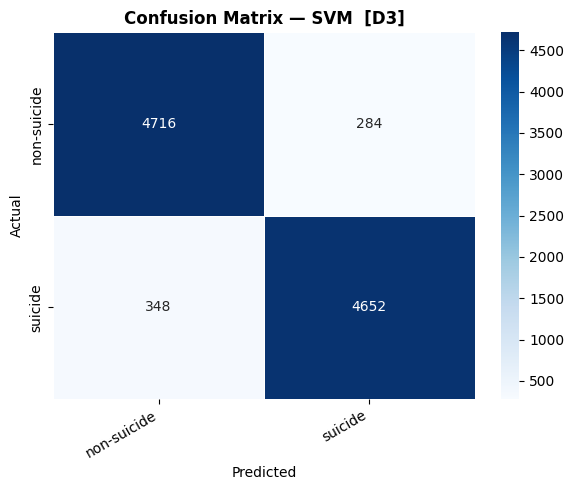

   Saved: svm_d3.pkl  (469 KB)

Training XGBoost...

  XGBoost  [D3]
  Accuracy     : 91.62%
  Macro F1     : 0.9162   ← main metric
  Cohen's Kappa: 0.8324   ← agreement beyond chance

              precision    recall  f1-score   support

 non-suicide      0.899     0.938     0.918      5000
     suicide      0.935     0.894     0.914      5000

    accuracy                          0.916     10000
   macro avg      0.917     0.916     0.916     10000
weighted avg      0.917     0.916     0.916     10000



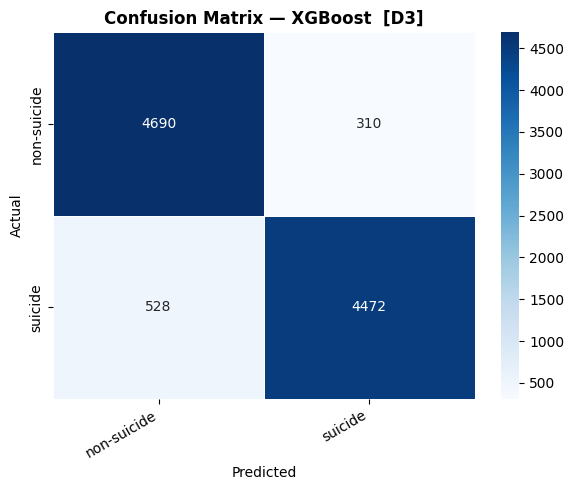

   Saved: xgboost_d3.pkl  (701 KB)

══════════════════════════════════════════════════════════
  SUMMARY — D3 — Suicide Risk
══════════════════════════════════════════════════════════
  Model                      Accuracy   Macro F1    Kappa
  ------------------------------------------------------
  Logistic Regression          0.9318     0.9318   0.8636
  Random Forest                0.8800     0.8800   0.7600
  SVM                          0.9368     0.9368   0.8736 ★
  XGBoost                      0.9162     0.9162   0.8324
══════════════════════════════════════════════════════════


✅ Dataset 3 complete! All files saved to Drive.


In [ ]:
# ─────────────────────────────────────────────────────────────────
# D3 — TRAIN + EVALUATE 4 CLASSICAL MODELS
# No class_weight='balanced' needed — data is already balanced
# ─────────────────────────────────────────────────────────────────
d3_results = {}

models_d3 = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42, n_jobs=-1),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1),
    'SVM': LinearSVC(
        C=1.0, max_iter=2000, random_state=42),
    'XGBoost': XGBClassifier(
        n_estimators=300, learning_rate=0.1, max_depth=6,
        eval_metric='logloss', random_state=42, n_jobs=-1)
}

for name, model in models_d3.items():
    print(f'\nTraining {name}...')
    model.fit(X3_tr_tf, y3_tr)   # no SMOTE — already balanced
    preds = model.predict(X3_te_tf)
    evaluate_model(name, y3_te, preds, le3.classes_, 'D3', d3_results)
    safe = name.lower().replace(' ', '_')
    save_pkl(model, f'{safe}_d3.pkl')

ALL_RESULTS['D3 Suicide Risk'] = d3_results
summary_table(d3_results, 'D3 — Suicide Risk')
print('\n✅ Dataset 3 complete! All files saved to Drive.')

---
# 📊 CLASSICAL MODEL SUMMARY
All 12 classical models trained. Here's the full cross-dataset comparison.

In [ ]:
# ─────────────────────────────────────────────────────────────────
# MASTER COMPARISON TABLE — All 12 classical models
# ─────────────────────────────────────────────────────────────────
import pandas as pd
rows = []
for ds, res in ALL_RESULTS.items():
    for model, scores in res.items():
        rows.append({'Dataset': ds, 'Model': model,
                     'Accuracy': scores['accuracy'],
                     'Macro F1': scores['macro_f1'],
                     "Cohen's Kappa": scores['kappa']})

master = pd.DataFrame(rows)
print('CLASSICAL MODELS — MASTER RESULTS')
print(master.to_string(index=False))

# Save table
master.to_csv(os.path.join(SAVE_DIR, 'classical_results.csv'), index=False)
print('\nSaved: classical_results.csv')

CLASSICAL MODELS — MASTER RESULTS
             Dataset               Model  Accuracy  Macro F1  Cohen's Kappa
  D1 Depression Type Logistic Regression    0.9152    0.9179         0.8971
  D1 Depression Type       Random Forest    0.9089    0.9129         0.8891
  D1 Depression Type                 SVM    0.9236    0.9269         0.9072
  D1 Depression Type             XGBoost    0.9176    0.9217         0.9000
D2 Binary Depression Logistic Regression    0.9889    0.9839         0.9678
D2 Binary Depression       Random Forest    0.9918    0.9880         0.9760
D2 Binary Depression                 SVM    0.9709    0.9589         0.9177
D2 Binary Depression             XGBoost    0.9927    0.9895         0.9789
     D3 Suicide Risk Logistic Regression    0.9318    0.9318         0.8636
     D3 Suicide Risk       Random Forest    0.8800    0.8800         0.7600
     D3 Suicide Risk                 SVM    0.9368    0.9368         0.8736
     D3 Suicide Risk             XGBoost    0.9162    

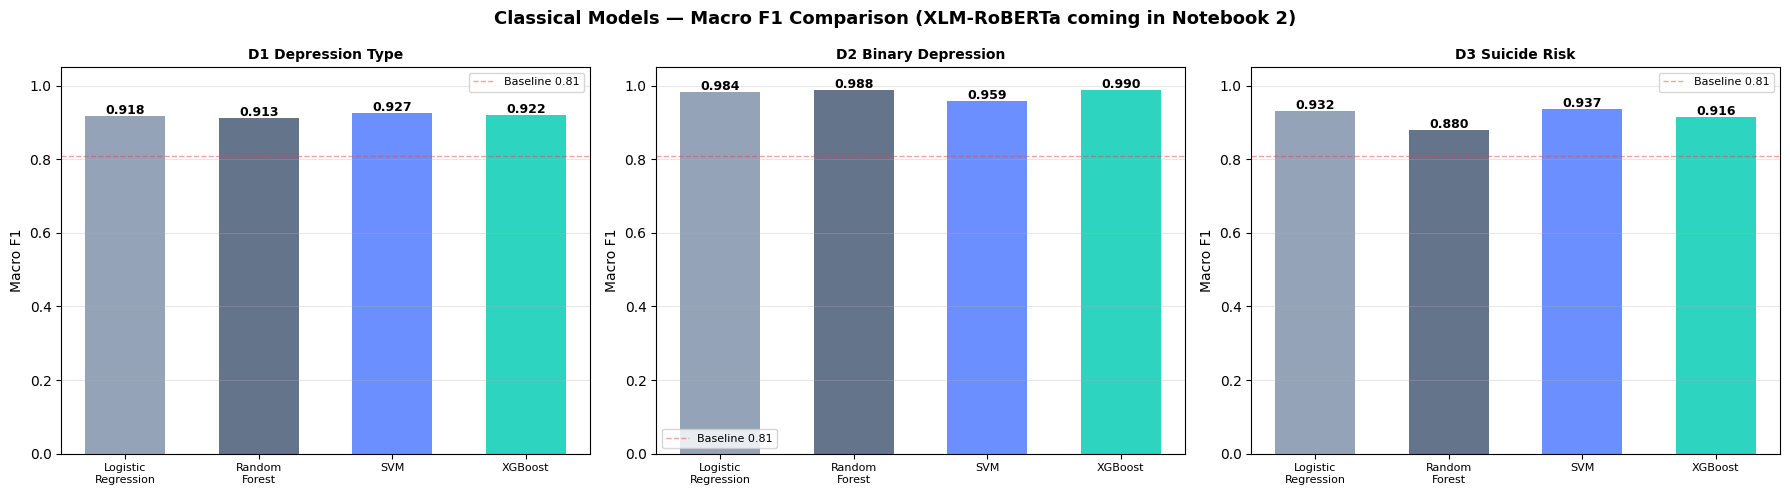

Chart saved: /content/drive/MyDrive/MindScan_Models/classical/classical_comparison.png


In [ ]:
# ─────────────────────────────────────────────────────────────────
# GROUPED BAR CHART — Classical models comparison
# XLM-RoBERTa results will be added in Notebook 2
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Classical Models — Macro F1 Comparison (XLM-RoBERTa coming in Notebook 2)',
             fontsize=13, fontweight='bold')

model_colors = {
    'Logistic Regression': '#94a3b8',
    'Random Forest':   ()     '#64748b',
    'SVM':                  '#6c8fff',
    'XGBoost':              '#2dd4bf',
}

for ax, (ds_name, ds_res) in zip(axes, ALL_RESULTS.items()):
    models = list(ds_res.keys())
    f1s    = [ds_res[m]['macro_f1'] for m in models]
    colors = [model_colors.get(m, '#6b7280') for m in models]
    bars = ax.bar(range(len(models)), f1s, color=colors, edgecolor='none', width=0.6)
    for bar, score in zip(bars, f1s):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{score:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(ds_name, fontsize=10, fontweight='bold')
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels([m.replace(' ','\n') for m in models], fontsize=8)
    ax.set_ylabel('Macro F1'); ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(0.81, color='#ef4444', linestyle='--', alpha=0.5,
               linewidth=1, label='Baseline 0.81')
    ax.legend(fontsize=8)

plt.tight_layout()
chart_path = os.path.join(SAVE_DIR, 'classical_comparison.png')
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved: {chart_path}')

In [ ]:
# ─────────────────────────────────────────────────────────────────
# FINAL FILE LIST — confirm everything is in Drive
# ─────────────────────────────────────────────────────────────────
print(f'Files in {SAVE_DIR}:')
for f in sorted(os.listdir(SAVE_DIR)):
    size = os.path.getsize(os.path.join(SAVE_DIR, f)) / 1024 / 1024
    print(f'  ✅ {f}  ({size:.1f} MB)')

print(f'\n✅ Notebook 1 complete!')
print(f'Next step: Run Notebook 2 (xlmr_transformer_notebook.ipynb) with T4 GPU enabled.')

Files in /content/drive/MyDrive/MindScan_Models/classical:
  ✅ classical_comparison.png  (0.1 MB)
  ✅ classical_results.csv  (0.0 MB)
  ✅ cm_D1_Logistic_Regression.png  (0.1 MB)
  ✅ cm_D1_Random_Forest.png  (0.1 MB)
  ✅ cm_D1_SVM.png  (0.1 MB)
  ✅ cm_D1_XGBoost.png  (0.1 MB)
  ✅ cm_D2_Logistic_Regression.png  (0.0 MB)
  ✅ cm_D2_Random_Forest.png  (0.0 MB)
  ✅ cm_D2_SVM.png  (0.0 MB)
  ✅ cm_D2_XGBoost.png  (0.0 MB)
  ✅ cm_D3_Logistic_Regression.png  (0.0 MB)
  ✅ cm_D3_Random_Forest.png  (0.0 MB)
  ✅ cm_D3_SVM.png  (0.0 MB)
  ✅ cm_D3_XGBoost.png  (0.0 MB)
  ✅ eda_d1.png  (0.1 MB)
  ✅ eda_d2.png  (0.1 MB)
  ✅ eda_d3.png  (0.1 MB)
  ✅ le_d1.pkl  (0.0 MB)
  ✅ le_d2.pkl  (0.0 MB)
  ✅ le_d3.pkl  (0.0 MB)
  ✅ logistic_regression_d1.pkl  (1.6 MB)
  ✅ logistic_regression_d2.pkl  (0.1 MB)
  ✅ logistic_regression_d3.pkl  (0.5 MB)
  ✅ random_forest_d1.pkl  (240.4 MB)
  ✅ random_forest_d2.pkl  (71.7 MB)
  ✅ random_forest_d3.pkl  (333.9 MB)
  ✅ svm_d1.pkl  (1.6 MB)
  ✅ svm_d2.pkl  (0.1 MB)
  ✅ svm_d3